# This notebook is used for the comparison of the VCFs obtained before and after replacing fgbio by fgumi in the deepUMIcaller pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vcf2maf import main_vcf_reader, vartype

In [2]:
fgbio_files_dir = "./fgbio"
fgumi_files_dir = "."

In [3]:
all_data_list = []
for sample in ["B5", "B7", "B13"]:
    print(f"Processing sample {sample}:")
    fgbio_df = main_vcf_reader(f"{fgbio_files_dir}/{sample}.vcf", sample, "fgbio", 3)
    all_data_list.append(fgbio_df)
    fgumi_df = main_vcf_reader(f"{fgumi_files_dir}/{sample}.vcf", sample, "fgumi", 3)
    all_data_list.append(fgumi_df)

all_data = pd.concat(all_data_list, ignore_index=True)

Processing sample B5:
Processing B5
Total mutations: 25
MUT_ID generated
Processing B5
Total mutations: 34
MUT_ID generated
Processing sample B7:
Processing B7
Total mutations: 26
MUT_ID generated
Processing B7
Total mutations: 27
MUT_ID generated
Processing sample B13:
Processing B13
Total mutations: 30
MUT_ID generated
Processing B13
Total mutations: 44
MUT_ID generated


/home/fcalvet/projects/deepUMIcaller/tests/test_data/expected_output/vcf2maf.py:203: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dat_full_reduced["MUT_ID"] = [ f'{row[0]}:{row[1]}_{row[2]}>{row[3]}' for _, row in dat_full_reduced.iterrows() ]
/home/fcalvet/projects/deepUMIcaller/tests/test_data/expected_output/vcf2maf.py:203: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dat_full_reduced["MUT_ID"] = [ f'{row[0]}:{row[1]}_{row[2]}>{row[3]}' for _, row in dat_full_reduced.iterrows() ]
/home/fcalvet/projects/deepUMIcaller/tests/test_data/expected_output/vcf2maf.py:203: FutureWarning: Series.__getitem__ treating keys a

In [4]:
all_data

,CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,SAMPLE,DEPTH,ALT_DEPTH,...,VAF_distorted_expanded,VAF_distorted_expanded_sq,VAF_distortion,VAF_distortion_sq,PMEAN,PSTD,MUT_ID,SAMPLE_ID,METHOD,TYPE
0,chr17,7670535,G,A,pSTD,SAMPLE=B5;TYPE=SNV;DP=9057;VD=1;AF=0.0001;BIAS...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"0/1:9057:1:9056,1:0.0001:9050,6:1,0:9057:9056,...",9057,1,...,False,False,1.122027,1.012798,73.0,0.0,chr17:7670535_G>A,B5,fgbio,SNV
1,chr17,7670633,G,C,pSTD,SAMPLE=B5;TYPE=SNV;DP=9061;VD=1;AF=0.0001;BIAS...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"0/1:9061:1:9060,1:0.0001:8951,109:1,0:9061:906...",9061,1,...,False,False,0.561679,0.940463,49.0,0.0,chr17:7670633_G>C,B5,fgbio,SNV
2,chr17,7670871,ATATT,A,low_complex;pSTD,SAMPLE=B5;TYPE=Deletion;DP=9057;VD=1;AF=0.0001...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"0/1:9057:1:9056,1:0.0001:1,9055:0,1:9063:9062,...",9063,1,...,True,False,8.976600,1.317264,74.0,0.0,chr17:7670871_ATATT>A,B5,fgbio,DELETION
3,chr17,7670926,C,A,low_complex;n_rich;pSTD,SAMPLE=B5;TYPE=SNV;DP=8568;VD=1;AF=0.0001;BIAS...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"0/1:8568:1:8567,1:0.0001:0,8567:0,1:8568:8567,...",8568,1,...,False,False,0.555822,0.939096,24.0,0.0,chr17:7670926_C>A,B5,fgbio,SNV
4,chr17,7673828,T,C,n_rich,SAMPLE=B5;TYPE=SNV;DP=10734;VD=3;AF=0.0003;BIA...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"0/1:10734:3:10731,3:0.0003:88,10643:0,3:10734:...",10734,3,...,False,False,0.732034,0.963279,67.3,1.0,chr17:7673828_T>C,B5,fgbio,SNV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,chr17,7676829,C,A,NM20;low_complex;pSTD,SAMPLE=B13;TYPE=SNV;DP=6294;VD=2;AF=0.0003;BIA...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"0/1:6294:2:6292,2:0.0003:0,6292:0,2:6294:6292,...",6294,2,...,False,False,0.997622,0.999705,69.0,0.0,chr17:7676829_C>A,B13,fgumi,SNV
182,chr17,7676883,C,A,NM20;low_complex;n_rich,SAMPLE=B13;TYPE=SNV;DP=5746;VD=1;AF=0.0002;BIA...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"0/1:5746:1:5745,1:0.0002:0,5745:0,1:5746:5745,...",5746,1,...,False,False,0.995151,0.999439,15.0,0.0,chr17:7676883_C>A,B13,fgumi,SNV
183,chrX,8204266,G,T,nanoseq_snp,SAMPLE=B13;TYPE=SNV;DP=1;VD=1;AF=1;BIAS=0:0;RE...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"1/1:1:1:0,1:1.0:0,0:1,0:1:0,1:0:63:0:1:0,1:0",1,1,...,False,False,1.000000,NaN,63.0,0.0,chrX:8204266_G>T,B13,fgumi,SNV
184,chrX,8204318,G,A,nanoseq_snp,SAMPLE=B13;TYPE=SNV;DP=1;VD=1;AF=1;BIAS=0:0;RE...,GT:DP:VD:AD:AF:RD:ALD:CDP:CAD:NDP:PMN:PST:CDPA...,"1/1:1:1:0,1:1.0:0,0:1,0:1:0,1:0:45:0:1:0,1:0",1,1,...,False,False,1.000000,NaN,45.0,0.0,chrX:8204318_G>A,B13,fgumi,SNV


In [5]:
all_data.columns

Index(['CHROM', 'POS', 'REF', 'ALT', 'FILTER', 'INFO', 'FORMAT', 'SAMPLE',
       'DEPTH', 'ALT_DEPTH', 'REF_DEPTH', 'VAF', 'vd_DEPTH', 'vd_ALT_DEPTH',
       'vd_REF_DEPTH', 'vd_VAF', 'numNs', 'VAF_Ns', 'DEPTH_AM', 'ALT_DEPTH_AM',
       'REF_DEPTH_AM', 'VAF_AM', 'numNs_AM', 'VAF_Ns_AM', 'DEPTH_ND',
       'ALT_DEPTH_ND', 'VAF_ND', 'VAF_distorted_expanded',
       'VAF_distorted_expanded_sq', 'VAF_distortion', 'VAF_distortion_sq',
       'PMEAN', 'PSTD', 'MUT_ID', 'SAMPLE_ID', 'METHOD', 'TYPE'],
      dtype='object')

## 1. Mutation overlap: shared vs method-specific

Mutations are keyed by `MUT_ID` (`CHROM:POS_REF>ALT`). For each sample we count how many mutations are found by both pipelines (fgbio and fgumi) and how many are exclusive to one of them.

In [6]:
# Build the mutation sets per sample and method
mut_sets = {
    (sample, method): set(
        df.loc[df["MUT_ID"].notna(), "MUT_ID"]
    )
    for (sample, method), df in all_data.groupby(["SAMPLE_ID", "METHOD"])
}

samples = sorted({s for s, _ in mut_sets})
methods = sorted({m for _, m in mut_sets})

overlap_rows = []
for sample in samples:
    sets = {m: mut_sets.get((sample, m), set()) for m in methods}
    shared = set.intersection(*sets.values()) if len(sets) > 1 else sets[methods[0]]
    union = set.union(*sets.values()) if len(sets) > 1 else sets[methods[0]]
    row = {"sample": sample, "union": len(union), "shared": len(shared)}
    for m in methods:
        row[f"only_{m}"] = len(sets[m] - set().union(*[v for k, v in sets.items() if k != m])) if len(sets) > 1 else 0
        row[f"total_{m}"] = len(sets[m])
    overlap_rows.append(row)

overlap_df = pd.DataFrame(overlap_rows)
overlap_df["jaccard"] = overlap_df["shared"] / overlap_df["union"]
print(overlap_df.to_string(index=False))

# Long format for plotting
plot_rows = []
for sample in samples:
    sets = {m: mut_sets.get((sample, m), set()) for m in methods}
    shared = set.intersection(*sets.values())
    for m in methods:
        plot_rows.append({"sample": sample, "category": f"only_{m}", "n": len(sets[m] - shared)})
    plot_rows.append({"sample": sample, "category": "shared", "n": len(shared)})
overlap_long = pd.DataFrame(plot_rows)


sample  union  shared  only_fgbio  total_fgbio  only_fgumi  total_fgumi  jaccard
   B13     45      29           1           30          15           44 0.644444
    B5     35      24           1           25          10           34 0.685714
    B7     28      25           1           26           2           27 0.892857


## 2. Shared mutations: are the annotations identical?

For mutations found by both pipelines, we compare the per-mutation fields: FILTER status, mutation type, and the depth/VAF metrics (duplex level `DEPTH`/`ALT_DEPTH`/`VAF` and all-molecules level `*_AM`).

In [7]:
# Fields to compare between the two methods for shared mutations
compare_fields = [
    "FILTER", "TYPE",
    "DEPTH", "ALT_DEPTH", "REF_DEPTH", "VAF",
    "DEPTH_AM", "ALT_DEPTH_AM", "REF_DEPTH_AM", "VAF_AM",
    "numNs", "numNs_AM",
    "PMEAN", "PSTD",
]

# Keep only the fields that actually exist in the parsed data
compare_fields = [c for c in compare_fields if c in all_data.columns]
print("Comparing fields:", compare_fields)

# Wide dataframe: one row per shared mutation, one column set per method
shared_pairs = []
for sample in samples:
    sets = {m: mut_sets.get((sample, m), set()) for m in methods}
    shared_ids = set.intersection(*sets.values())
    if not shared_ids:
        continue
    fg = all_data[(all_data["SAMPLE_ID"] == sample) & (all_data["METHOD"] == "fgbio") & (all_data["MUT_ID"].isin(shared_ids))]
    gu = all_data[(all_data["SAMPLE_ID"] == sample) & (all_data["METHOD"] == "fgumi") & (all_data["MUT_ID"].isin(shared_ids))]
    fg = fg.set_index("MUT_ID").add_suffix("_fgbio")
    gu = gu.set_index("MUT_ID").add_suffix("_fgumi")
    merged = fg.join(gu, how="inner")
    merged["SAMPLE_ID"] = sample
    shared_pairs.append(merged.reset_index())

shared_df = pd.concat(shared_pairs, ignore_index=True) if shared_pairs else pd.DataFrame()
print(f"Shared mutations pooled across samples: {len(shared_df)}")


Comparing fields: ['FILTER', 'TYPE', 'DEPTH', 'ALT_DEPTH', 'REF_DEPTH', 'VAF', 'DEPTH_AM', 'ALT_DEPTH_AM', 'REF_DEPTH_AM', 'VAF_AM', 'numNs', 'numNs_AM', 'PMEAN', 'PSTD']
Shared mutations pooled across samples: 78


In [8]:
# Categorical fields: exact match rate per sample
cat_fields = [c for c in ["FILTER", "TYPE"] if f"{c}_fgbio" in shared_df.columns]
match_rows = []
for sample in samples:
    sub = shared_df[shared_df["SAMPLE_ID"] == sample]
    row = {"sample": sample, "n_shared": len(sub)}
    for c in cat_fields:
        row[f"{c}_match_%"] = (sub[f"{c}_fgbio"] == sub[f"{c}_fgumi"]).mean() * 100
    match_rows.append(row)
match_df = pd.DataFrame(match_rows)
print(match_df.to_string(index=False))

# FILTER agreement detail: which filter labels differ
if "FILTER_fgbio" in shared_df.columns:
    filt_diff = shared_df[shared_df["FILTER_fgbio"] != shared_df["FILTER_fgumi"]]
    print(f"\nShared mutations with different FILTER: {len(filt_diff)} / {len(shared_df)}")
    if len(filt_diff):
        display(filt_diff[["SAMPLE_ID", "MUT_ID", "FILTER_fgbio", "FILTER_fgumi"]].head(20))


sample  n_shared  FILTER_match_%  TYPE_match_%
   B13        29       34.482759         100.0
    B5        24       25.000000         100.0
    B7        25       28.000000         100.0

Shared mutations with different FILTER: 55 / 78


,SAMPLE_ID,MUT_ID,FILTER_fgbio,FILTER_fgumi
0,B13,chr17:7669429_CA>C,pSTD,PASS
1,B13,chr17:7669510_C>A,pSTD,n_rich
2,B13,chr17:7669577_G>T,pSTD,PASS
3,B13,chr17:7670626_C>A,p10;pSTD,p10
4,B13,chr17:7670918_C>A,low_complex;n_rich;pSTD,NM20;low_complex
5,B13,chr17:7673703_C>T,pSTD,PASS
6,B13,chr17:7673833_TACC>T,pSTD,PASS
7,B13,chr17:7673895_C>T,n_rich;pSTD,PASS
8,B13,chr17:7674226_A>T,pSTD,PASS
9,B13,chr17:7674232_C>T,pSTD,PASS


In [9]:
# Numeric fields: differences between methods for shared mutations
num_fields = [c for c in compare_fields if c not in cat_fields and f"{c}_fgbio" in shared_df.columns]

diff_rows = []
for sample in samples:
    sub = shared_df[shared_df["SAMPLE_ID"] == sample]
    row = {"sample": sample, "n_shared": len(sub)}
    for c in num_fields:
        a = pd.to_numeric(sub[f"{c}_fgbio"], errors="coerce")
        b = pd.to_numeric(sub[f"{c}_fgumi"], errors="coerce")
        row[f"{c}_identical_%"] = (a == b).mean() * 100
        row[f"{c}_median_diff"] = (b - a).median()
    diff_rows.append(row)
diff_df = pd.DataFrame(diff_rows)
print(diff_df.round(3).to_string(index=False))


sample  n_shared  DEPTH_identical_%  DEPTH_median_diff  ALT_DEPTH_identical_%  ALT_DEPTH_median_diff  REF_DEPTH_identical_%  REF_DEPTH_median_diff  VAF_identical_%  VAF_median_diff  DEPTH_AM_identical_%  DEPTH_AM_median_diff  ALT_DEPTH_AM_identical_%  ALT_DEPTH_AM_median_diff  REF_DEPTH_AM_identical_%  REF_DEPTH_AM_median_diff  VAF_AM_identical_%  VAF_AM_median_diff  numNs_identical_%  numNs_median_diff  numNs_AM_identical_%  numNs_AM_median_diff  PMEAN_identical_%  PMEAN_median_diff  PSTD_identical_%  PSTD_median_diff
   B13        29             10.345              440.0                 72.414                    0.0                 24.138                  350.0           24.138             -0.0                10.345               -7012.0                    55.172                       0.0                     20.69                   -7004.0              17.241                 0.0             10.345               60.0                10.345                 -62.0             82.759      

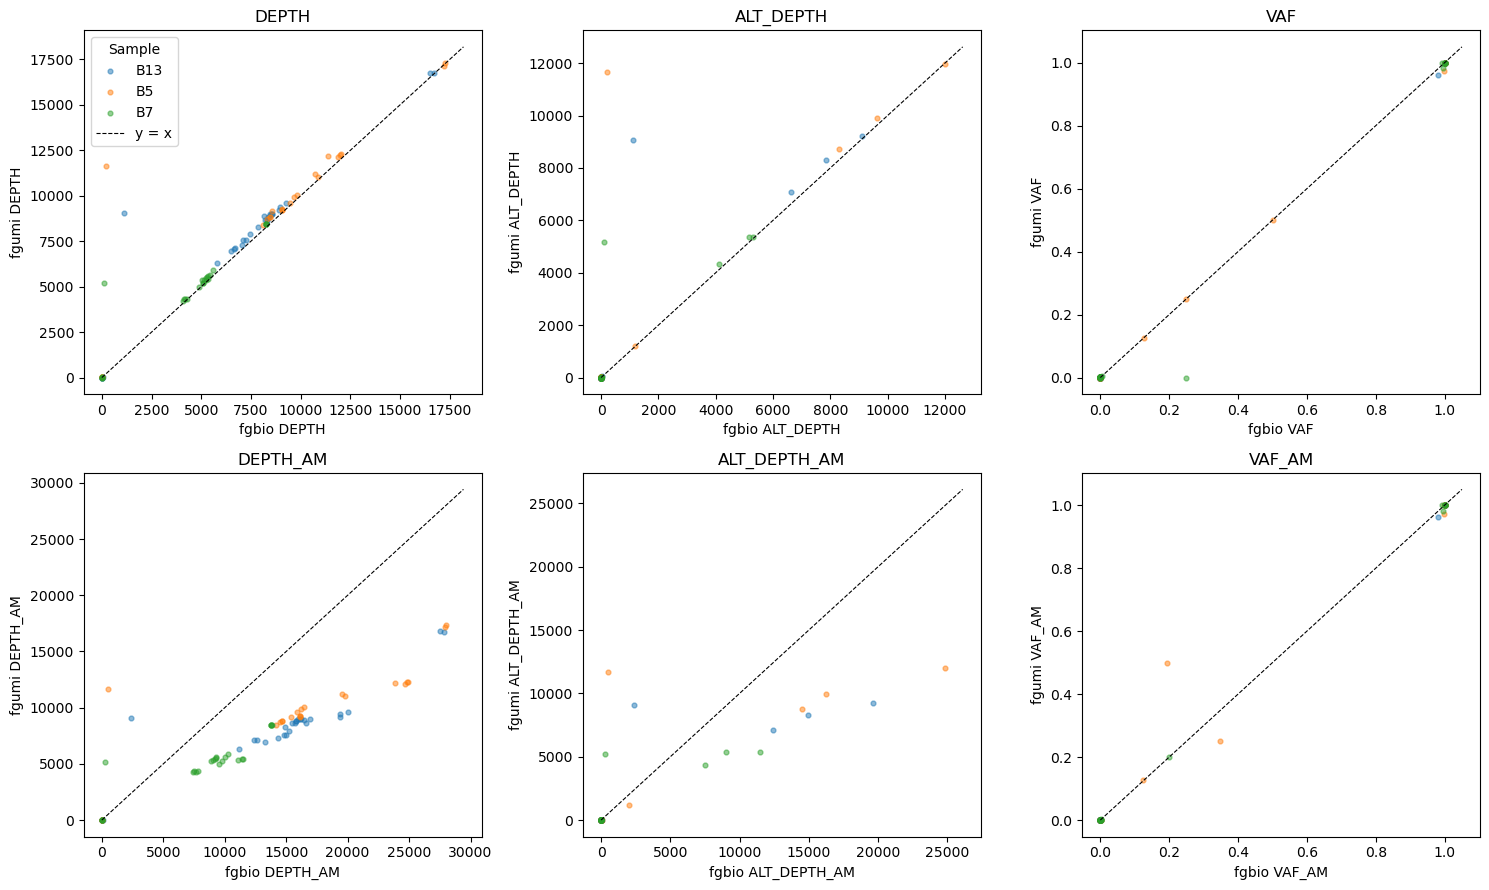

In [10]:
# Scatter plots: fgbio vs fgumi for the key depth/VAF fields (duplex level)
key_fields = [c for c in ["DEPTH", "ALT_DEPTH", "VAF", "DEPTH_AM", "ALT_DEPTH_AM", "VAF_AM"] if f"{c}_fgbio" in shared_df.columns]

if key_fields:
    n = len(key_fields)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, field in zip(axes, key_fields):
        for sample in samples:
            sub = shared_df[shared_df["SAMPLE_ID"] == sample]
            a = pd.to_numeric(sub[f"{field}_fgbio"], errors="coerce")
            b = pd.to_numeric(sub[f"{field}_fgumi"], errors="coerce")
            ax.scatter(a, b, s=12, alpha=0.5, label=sample)

        max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
        ax.plot([0, max_val], [0, max_val], "k--", lw=0.8, label="y = x")
        ax.set_xlabel(f"fgbio {field}")
        ax.set_ylabel(f"fgumi {field}")
        ax.set_title(field)
    axes[0].legend(title="Sample")

    # hide unused axes
    for ax in axes[len(key_fields):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


## 3. Method-specific mutations

Mutations found by only one pipeline — are they filtered out in the other VCF, or completely absent?

In [11]:
# For method-specific mutations: check whether they appear in the other VCF at all
# (they cannot, by construction of the sets) — instead summarize their FILTER distribution
# and VAF to see whether they are low-quality calls that one pipeline drops.
specific_rows = []
for sample in samples:
    sets = {m: mut_sets.get((sample, m), set()) for m in methods}
    shared = set.intersection(*sets.values())
    for m in methods:
        only_ids = sets[m] - shared
        sub = all_data[(all_data["SAMPLE_ID"] == sample) & (all_data["METHOD"] == m) & (all_data["MUT_ID"].isin(only_ids))]
        row = {"sample": sample, "method": m, "n_only": len(sub)}
        if len(sub):
            row["pass_%"] = (sub["FILTER"] == "PASS").mean() * 100
            row["median_VAF"] = pd.to_numeric(sub["VAF"], errors="coerce").median()
            row["median_DEPTH"] = pd.to_numeric(sub["DEPTH"], errors="coerce").median()
            row["top_filters"] = ", ".join(sub["FILTER"].value_counts().head(3).index.tolist())
        specific_rows.append(row)
specific_df = pd.DataFrame(specific_rows)
print(specific_df.round(3).to_string(index=False))


sample method  n_only  pass_%  median_VAF  median_DEPTH                                     top_filters
   B13  fgbio       1     0.0        0.00        8487.0                                            pSTD
   B13  fgumi      15     0.0        0.00        7749.0           NM20, NM20;n_rich, n_rich;nanoseq_snp
    B5  fgbio       1     0.0        0.25           4.0 NM20;low_complex;nanoseq_noise;nanoseq_snp;pSTD
    B5  fgumi      10    20.0        0.00        9151.5        PASS, NM20;nanoseq_snp, NM20;low_complex
    B7  fgbio       1     0.0        0.00        5248.0                                            pSTD
    B7  fgumi       2     0.0        0.00        4066.0                 low_complex, low_complex;n_rich


In [24]:
# Build dist_df: VAF of shared vs method-specific mutations, per sample and method
dist_rows = []
for sample in samples:
    sets = {m: mut_sets.get((sample, m), set()) for m in methods}
    shared = set.intersection(*sets.values())
    for m in methods:
        sub = all_data[(all_data["SAMPLE_ID"] == sample) & (all_data["METHOD"] == m)]
        shared_sub = sub[sub["MUT_ID"].isin(shared)]
        only_sub = sub[sub["MUT_ID"].isin(sets[m] - shared)]
        for _, r in shared_sub.iterrows():
            dist_rows.append({"SAMPLE_ID": sample, "METHOD": m, "category": "shared", "VAF": r["VAF"]})
        for _, r in only_sub.iterrows():
            dist_rows.append({"SAMPLE_ID": sample, "METHOD": m, "category": f"only_{m}", "VAF": r["VAF"]})

dist_df = pd.DataFrame(dist_rows)
dist_df["VAF"] = pd.to_numeric(dist_df["VAF"], errors="coerce")


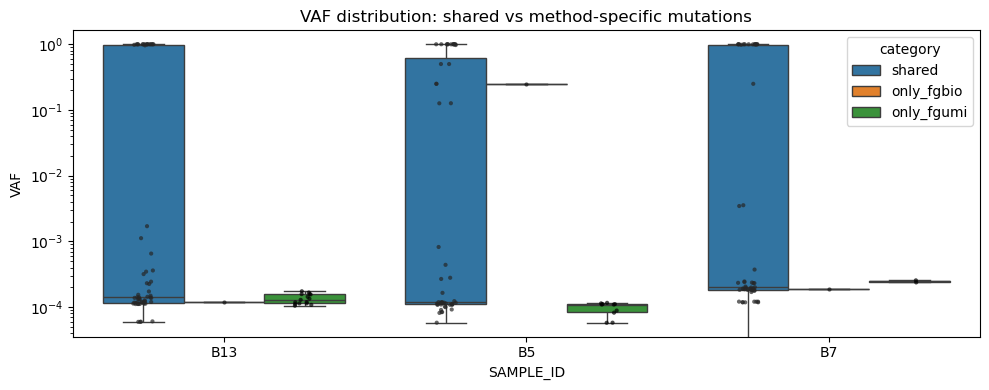

In [28]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=dist_df, x="SAMPLE_ID", y="VAF", hue="category",
            showfliers=False)
sns.stripplot(data=dist_df, x="SAMPLE_ID", y="VAF", size=3,
              hue="category",
              dodge=True,
              alpha=0.7, jitter=True,
              palette='dark:black',
              legend=False
              )
plt.yscale("log")
plt.title("VAF distribution: shared vs method-specific mutations")
plt.tight_layout()
plt.show()